# Practica sobre variable aleatoria

## Objetivos:
1. Evaluar diferentes condiciones necesarias y suficientes para el cumplimiento del Teorema del Límite Central.
2. Evaluar el concepto de ergocicidad en un proceso aleatorio. Para el caso específico del Movimiento Browniano.
3. Aplicar los conceptos de pruebas de hipótesis y normalidad para comparar grupos de datos.

## Teorema del Límite Central (TLC)

El Teorema del Límite Central establece que la suma (o promedio) de un número
grande de variables aleatorias independientes e idénticamente distribuidas (iid)
tiende a seguir una distribución Normal (Gaussiana), sin importar la distribución
original de cada variable.


## Distribución Uniforme $U[a, b]$

Para una VA Uniforme en el intervalo $[a, b]$, su función de densidad es constante:

$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

con media y varianza:

$$\mu = \frac{a+b}{2}, \qquad \sigma^2 = \frac{(b-a)^2}{12}$$

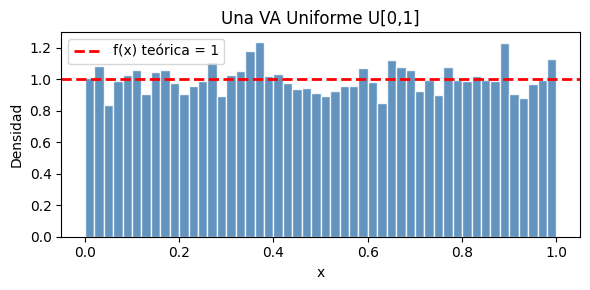

Media muestral:   0.5007  | Teórica: 0.5000
Std   muestral:   0.2890  | Teórica: 0.2887


In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
muestras_uniforme = np.random.uniform(0, 1, N)

plt.figure(figsize=(6, 3))
plt.hist(muestras_uniforme, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.85)
plt.axhline(1, color='red', linestyle='--', lw=2, label='f(x) teórica = 1')
plt.title('Una VA Uniforme U[0,1]')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Media muestral:   {muestras_uniforme.mean():.4f}  | Teórica: {(0+1)/2:.4f}")
print(f"Std   muestral:   {muestras_uniforme.std():.4f}  | Teórica: {np.sqrt((1-0)**2/12):.4f}")



## Distribución Exponencial

La distribución exponencial tiene la siguiente función de densidad:

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

Con media y desviación estándar:

$$\mu = \sigma = \frac{1}{\lambda}$$

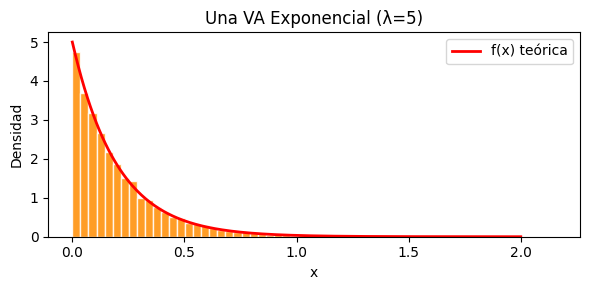

Media muestral: 0.2005 | Teórica: 0.2000
Std   muestral: 0.2011 | Teórica: 0.2000


In [2]:
lam = 5
muestras_exp = np.random.exponential(scale=1/lam, size=N)

plt.figure(figsize=(6, 3))
plt.hist(muestras_exp, bins=60, density=True, color='darkorange', edgecolor='white', alpha=0.85)

x = np.linspace(0, 2, 300)
plt.plot(x, lam * np.exp(-lam * x), 'r-', lw=2, label=f'f(x) teórica')
plt.title(f'Una VA Exponencial (λ={lam})')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Media muestral: {muestras_exp.mean():.4f} | Teórica: {1/lam:.4f}")
print(f"Std   muestral: {muestras_exp.std():.4f} | Teórica: {1/lam:.4f}")

## Suma de VAs iid

Sean $X_1, X_2, \ldots, X_n$ VAs iid con media común $\mu$ y desviación estándar común $\sigma$. Particularmente nos interesa:

- Muestra total ($T$): $T = \sum_{i=1}^{n} X_i$
- Media muestral ($\bar{X}$): $\bar{X} = \frac{T}{n}$

$T$ y $\bar{X}$ tienen las siguientes propiedades:

|  | $T$ | $\bar{X}$ |
|--|-----|-----------|
| Media | $E[T] = n\mu$ | $E[\bar{X}] = \mu$ |
| Varianza | $\text{Var}(T) = n\sigma^2$ | $\text{Var}(\bar{X}) = \frac{\sigma^2}{n}$ |
| Desv. estándar | $\text{SD}(T) = \sqrt{n}\sigma$ | $\text{SD}(\bar{X}) = \frac{\sigma}{\sqrt{n}}$ |

Note que promediar pone los datos hacia el centro mientras que totalizar los dispersa.

El siguiente ejemplo ilustra esta diferencia para $n = 10$ VAs Uniformes $U[0,1]$ independientes a partir de 1000 realizaciones:

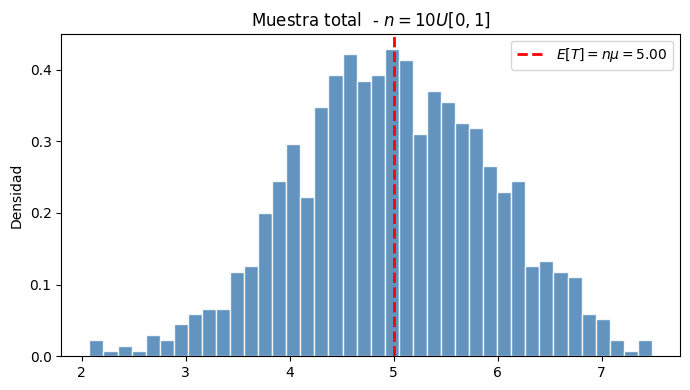

E[T]   estimada: 4.9898  | Teórica: 5.0000
Var(T) estimada: 0.8913  | Teórica: 0.8333


In [3]:
import numpy as np
import matplotlib.pyplot as plt

N, n = 1000, 10
mu    = 0.5
sigma2 = (1**2) / 12

muestras = np.random.uniform(0, 1, size=(N, n))
T = muestras.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(T, bins=40, density=True, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f'Muestra total  - $n={n}U[0,1]$')
plt.xlabel(''); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout()
plt.show()

print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")

Ahora analicemos la media muestral de la suma de VAs.

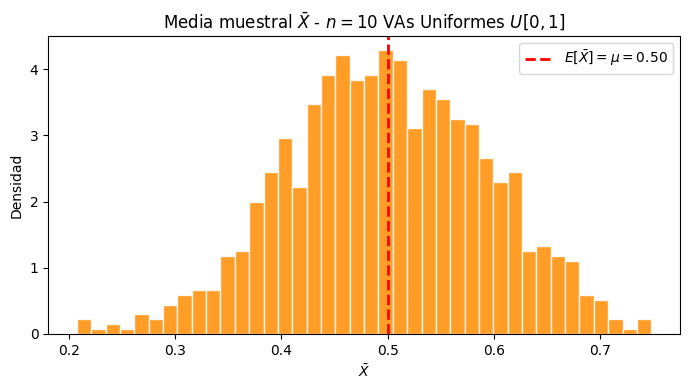

E[X_barra]   estimada: 0.4990  | Teórica: 0.5000
Var(X_barra) estimada: 0.0089  | Teórica: 0.0083


In [4]:
X_barra = muestras.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(X_barra, bins=40, density=True, color='darkorange', edgecolor='white', alpha=0.85)
plt.axvline(mu, color='red', linestyle='--', lw=2, label=f'$E[\\bar{{X}}] = \\mu = {mu:.2f}$')
plt.title(f'Media muestral $\\bar{{X}}$ - $n={n}$ VAs Uniformes $U[0,1]$')
plt.xlabel('$\\bar{X}$'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout()
plt.show()

print(f"E[X_barra]   estimada: {X_barra.mean():.4f}  | Teórica: {mu:.4f}")
print(f"Var(X_barra) estimada: {X_barra.var():.4f}  | Teórica: {sigma2/n:.4f}")


## Matriz de correlación de Pearson

El coeficiente de correlación de Pearson mide la dependencia lineal entre
dos variables. Para un par $(X_i, X_j)$:

$$\rho_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_i \cdot \sigma_j} \in [-1, 1]$$

| Valor de $\rho$. | Interpretación |
|----|----|
| $\rho \approx 1$ | Correlación positiva fuerte |
| $\rho \approx 0$ | Variables NO correlacionadas linealmente |
| $\rho \approx -1$ | Correlación negativa fuerte |

Cuando tenemos $n$ variables, podemos organizar todos los coeficientes en una
matriz de correlación $\mathcal{P} \in \mathbb{R}^{n\times n}$, donde:

- La diagonal principal siempre es 1 (cada variable consigo misma)
- La matriz es simétrica: $\rho_{ij} = \rho_{ji}$

Para variables independientes, esperamos que cada $\rho \in \mathcal{P}$ se aproxime a la matriz identidad; sin embargo, recuerde que $\rho=0$ no garantiza independencia.

Ahora, vamos a generar una matriz de correlación entre 10 VAs uniformes generadas en 1000 realizaciones.

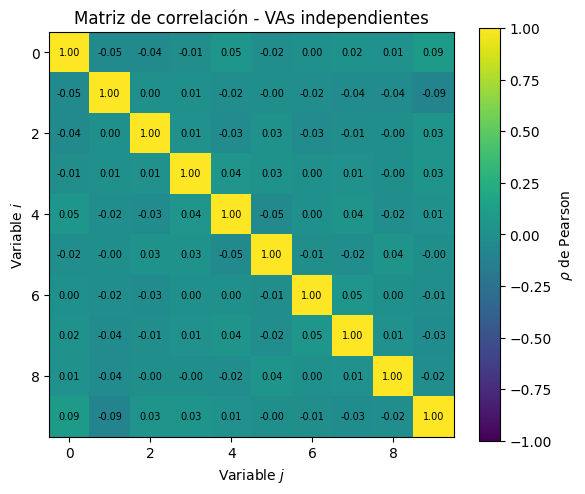

Correlación promedio entre pares: -0.0010
(Esperado ≈ 0 para variables independientes)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

N = 1000  # realizaciones
n = 10    # número de variables

# Generamos n VAs Uniformes independientes → shape (N, n)
muestras = np.random.uniform(0, 1, size=(N, n))

# Calculamos la matriz de correlación de Pearson [n x n]
R = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        r, _ = pearsonr(muestras[:, i], muestras[:, j])
        R[i, j] = r

# Visualización
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label=f'$\\rho$ de Pearson')

# Anotamos cada celda con su valor
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=7, color='black')

ax.set_title('Matriz de correlación - VAs independientes')
ax.set_xlabel('Variable $j$')
ax.set_ylabel('Variable $i$')
plt.tight_layout()
plt.show()

# Correlación promedio fuera de la diagonal
mask = ~np.eye(n, dtype=bool)
print(f"Correlación promedio entre pares: {R[mask].mean():.4f}")
print(f"(Esperado ≈ 0 para variables independientes)")

## Procesos Aleatorios

Un proceso aleatorio $X(t)$ es una colección de variables aleatorias
indexadas por el tiempo. Para cada instante $t$ fijo, $X(t)$ es una VA.
Para cada realización fija, $X(t)$ es una función determinista del tiempo.

Podemos estudiarlo desde dos perspectivas:

| Perspectiva | Descripción |
|---|---|
| **Media del ensamble** | Valor esperado sobre todas las realizaciones en un instante $t$ fijo |
| **Media temporal** | Valor esperado a lo largo del tiempo para una realización fija |



---
# **Laboratorio**
---

# Punto 1: Teorema del límite central




La media ($\mu$) y la desviación estándar ($\sigma$) de una Variable Aleatoria (VA) Uniforme ~ [a,b] está dada por la expresión: $\mu = \frac{a+b}{2}$ y $\sigma^2 = \frac{1}{12}(b-a)^2$.


1.1. Considere la suma de $n$ distribuciones con $n \in \{2,5,100,1000\}$ y grafique el histograma resultante para cada caso.


In [6]:
a, b = 0, 1
tamaño = 3
n = 2
muestras = np.sum(np.random.uniform(a, b, (n, tamaño)), axis=0)
print(muestras)

[0.69059593 0.98576114 1.18516008]


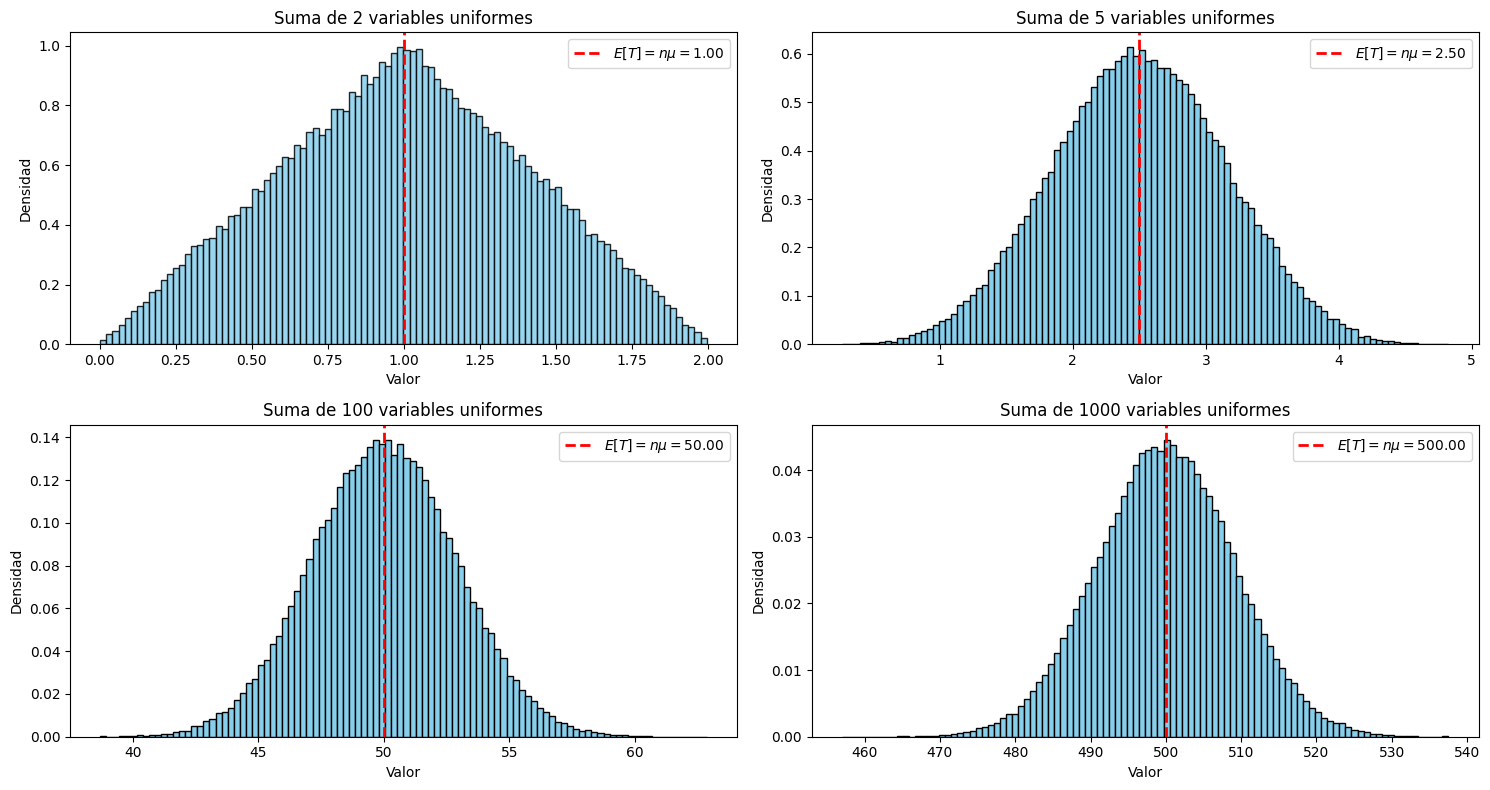

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la distribución uniforme
a, b = 0, 1
mu    = 0.5

#sigma2 = (1**2) / 12
sigma2 = (b - a)**2 / 12

tamaño = 100000
distribuciones = [2, 5, 100, 1000]

# Crear una figura con subplots
plt.figure(figsize=(15, 8))


# Subgráfica 1: Señal
n=distribuciones[0]
plt.subplot(2, 2, 1)
muestrasA = np.sum(np.random.uniform(a, b, (n, tamaño)), axis=0)
plt.hist(muestrasA, bins=100, density=True, color='skyblue', edgecolor='black', alpha=0.85)
plt.axvline(n * mu, color='red', linestyle='--', lw=2,label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f"Suma de {n} variables uniformes")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()


# Subgráfica 2: Señal
n=distribuciones[1]
plt.subplot(2, 2, 2)
muestrasB = np.sum(np.random.uniform(a, b, (n, tamaño)), axis=0)
plt.hist(muestrasB, bins=100, density=True, color='skyblue', edgecolor='black')
plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f"Suma de {n} variables uniformes")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

# Subgráfica 3: Señal
n=distribuciones[2]
plt.subplot(2, 2, 3)
muestrasC = np.sum(np.random.uniform(a, b, (n, tamaño)), axis=0)
plt.hist(muestrasC, bins=100, density=True, color='skyblue', edgecolor='black')
plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f"Suma de {n} variables uniformes")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

# Subgráfica 4: Señal
n=distribuciones[3]
plt.subplot(2, 2, 4)
muestrasD = np.sum(np.random.uniform(a, b, (n, tamaño)), axis=0)
plt.hist(muestrasD, bins=100, density=True, color='skyblue', edgecolor='black')
plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f"Suma de {n} variables uniformes")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

plt.show()

1.2. ¿Cuál es la distribución resultante del punto 1? Estime la media y la desviación estándar del resultado de la suma.
Compare con el caso teórico del punto anterior.

In [8]:

print(f"Suma de {distribuciones[0]} variables:")
n=distribuciones[0]
T=muestrasA
print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")
print(f"Desviación estándar estimada: {np.std(muestrasA)}")
print("-" * 50)

print(f"\nSuma de {distribuciones[1]} variables:")
n=distribuciones[1]
T=muestrasB
print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")
print(f"Desviación estándar estimada: {np.std(muestrasB)}")
print("-" * 50)

print(f"\nSuma de {distribuciones[2]} variables:")
n=distribuciones[2]
T=muestrasC
print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")
print(f"Desviación estándar estimada: {np.std(muestrasC)}")
print("-" * 50)

print(f"\nSuma de {distribuciones[3]} variables:")
n=distribuciones[3]
T=muestrasD
print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")
print(f"Desviación estándar estimada: {np.std(muestrasD)}")
print("-" * 50)



Suma de 2 variables:
E[T]   estimada: 1.0015  | Teórica: 1.0000
Var(T) estimada: 0.1662  | Teórica: 0.1667
Desviación estándar estimada: 0.4077112734306068
--------------------------------------------------

Suma de 5 variables:
E[T]   estimada: 2.5012  | Teórica: 2.5000
Var(T) estimada: 0.4203  | Teórica: 0.4167
Desviación estándar estimada: 0.648323677222969
--------------------------------------------------

Suma de 100 variables:
E[T]   estimada: 50.0058  | Teórica: 50.0000
Var(T) estimada: 8.2719  | Teórica: 8.3333
Desviación estándar estimada: 2.876096089876125
--------------------------------------------------

Suma de 1000 variables:
E[T]   estimada: 499.9630  | Teórica: 500.0000
Var(T) estimada: 83.1084  | Teórica: 83.3333
Desviación estándar estimada: 9.116378540944405
--------------------------------------------------


1.3. Considere ahora una VA exponencial, cuya distribución es: $F(\lambda)=\lambda e^{-\lambda x}$, con $\lambda=5$.
Realice el mismo procedimiento que realizó con las VA Uniformes y obtenga la media y desviación estandar, teniendo en cuenta que: $\mu = \sigma = \frac{1}{λ}$. Describa el comportamiento que se observa al realizar la suma de las $n$ distribuciones exponenciales.

Suma de 2 variables exponenciales:
Media experimental: 0.3988 | Teórica: 0.4000
Desviación estándar experimental: 0.2815 | Teórica: 0.2828
--------------------------------------------------
Suma de 5 variables exponenciales:
Media experimental: 0.9970 | Teórica: 1.0000
Desviación estándar experimental: 0.4459 | Teórica: 0.4472
--------------------------------------------------
Suma de 100 variables exponenciales:
Media experimental: 20.0041 | Teórica: 20.0000
Desviación estándar experimental: 2.0056 | Teórica: 2.0000
--------------------------------------------------
Suma de 1000 variables exponenciales:
Media experimental: 200.0160 | Teórica: 200.0000
Desviación estándar experimental: 6.3132 | Teórica: 6.3246
--------------------------------------------------


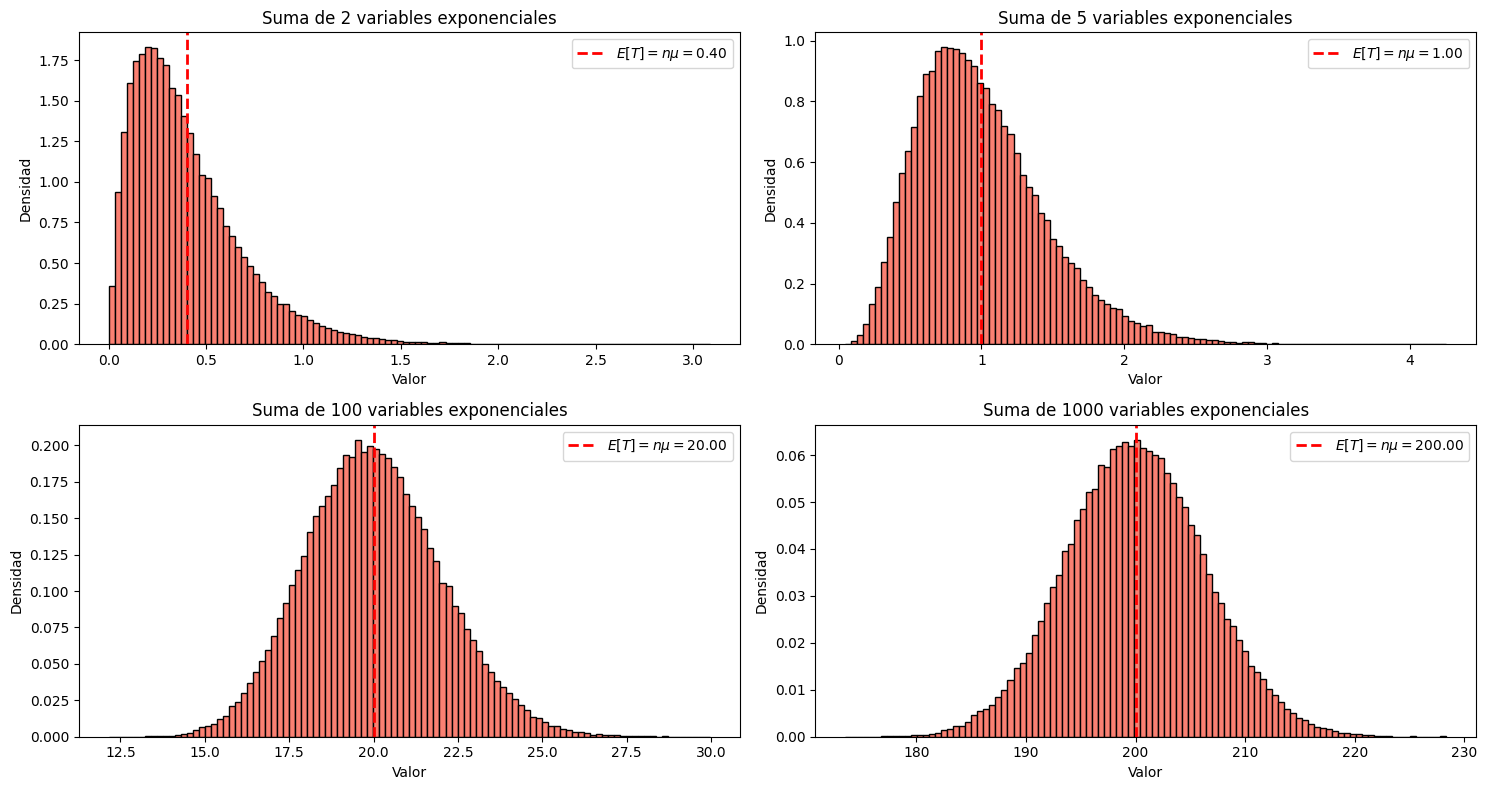

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la distribución exponencial
lambd = 5
mu_teorico = 1 / lambd
sigma_teorico = 1 / lambd

tamaño = 100000
distribuciones = [2, 5, 100, 1000]

plt.figure(figsize=(15, 8))

for i, n in enumerate(distribuciones):
    # Sumar n variables exponenciales
    muestras = np.sum(np.random.exponential(scale=1/lambd, size=(n, tamaño)), axis=0)

    # Calcular estadísticas experimental
    media = np.mean(muestras)
    varianza = np.var(muestras)
    desviacion = np.std(muestras)

    # Mostrar en consola
    print(f"Suma de {n} variables exponenciales:")
    print(f"Media experimental: {media:.4f} | Teórica: {n * mu_teorico:.4f}")
    print(f"Desviación estándar experimental: {desviacion:.4f} | Teórica: {(np.sqrt(n) * sigma_teorico):.4f}")
    print("-" * 50)

    # Graficar
    plt.subplot(2, 2, i + 1)
    plt.hist(muestras, bins=100, density=True, color='salmon', edgecolor='black')
    #plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
    plt.axvline(n * mu_teorico, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu_teorico:.2f}$')

    plt.title(f"Suma de {n} variables exponenciales")
    plt.xlabel("Valor")
    plt.ylabel("Densidad")
    plt.legend()
plt.tight_layout()
plt.show()


Es una distribución Gamma/Erlang. La aproximación gaussiana aparece cuando
n
 es suficientemente grande (compensacion)

# Punto 2:





### **Suma de VAs**

2.1. Considere 120 distribuciones uniformes, en grupos de 20 con diferentes valores de a y b por grupo, i.e., no son iid. Muestre que la suma total converge a una distribución Gaussiana después de 1000 realizaciones. Y analice si es posible encontrar valores teóricos de $\mu$ y $\sigma$. Concluya.

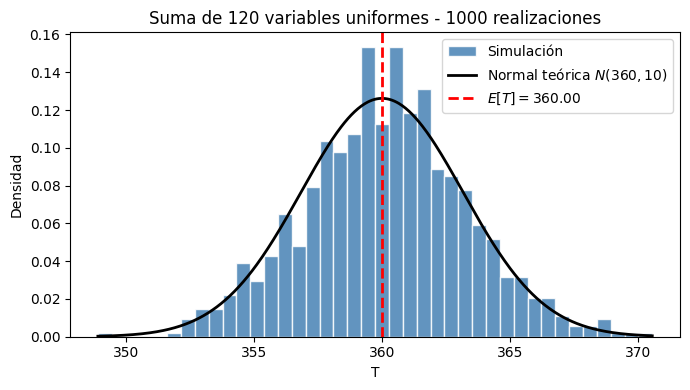

E[T] estimada:    360.1327 | Teórica: 360.0000
Var(T) estimada: 9.9079 | Teórica: 10.0000


In [10]:
import numpy as np
import matplotlib.pyplot as plt

N, n = 1000, 120

# 6 grupos de 20 variables, cada uno con diferente [a,b]
intervalos = [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6)]

muestras = np.zeros((N, n))

# Generar las 120 variables uniformes
for i, (a, b) in enumerate(intervalos):
    muestras[:, i*20:(i+1)*20] = np.random.uniform(a, b, size=(N, 20))

# Suma total de las 120 variables
T = muestras.sum(axis=1)

# Media teórica de la suma
mu_total = sum(20 * (a + b) / 2 for a, b in intervalos)

# Varianza teórica de la suma
sigma2_total = sum(20 * ((b - a)**2 / 12) for a, b in intervalos)
sigma_total = np.sqrt(sigma2_total)

plt.figure(figsize=(7, 4))
plt.hist(T, bins=40, density=True,color='steelblue', edgecolor='white', alpha=0.85,label='Simulación')

x = np.linspace(T.min(), T.max(), 500)
normal = ( 1/(sigma_total*np.sqrt(2*np.pi))* np.exp(-0.5*((x-mu_total)/sigma_total)**2))
#plt.plot(x,normal,color='black',linewidth=2,label=r'Normal teórica $N(360,10)$')
plt.plot(x,normal,color='black',linewidth=2,label=rf'Normal teórica $N({mu_total:.0f},{sigma2_total:.0f})$')



plt.axvline(mu_total, color='red', linestyle='--', lw=2, label=f'$E[T] = {mu_total:.2f}$')
plt.title(f'Suma de 120 variables uniformes - 1000 realizaciones')
plt.xlabel('T')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"E[T] estimada:    {T.mean():.4f} | Teórica: {mu_total:.4f}")
print(f"Var(T) estimada: {T.var():.4f} | Teórica: {sigma2_total:.4f}")


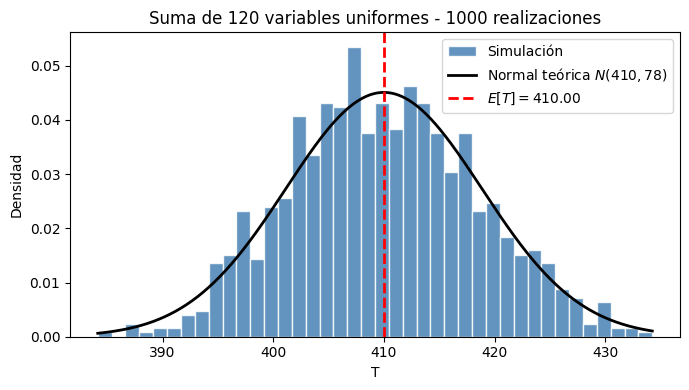

E[T] estimada:    409.9546 | Teórica: 410.0000
Var(T) estimada: 71.8245 | Teórica: 78.3333


In [11]:
import numpy as np
import matplotlib.pyplot as plt

N, n = 1000, 120

# 6 grupos de 20 variables, cada uno con diferente [a,b]
intervalos = [
    (0, 1), # valor esperado 0.5
    (2, 4), # valor esperado 3
    (-1, 1), # valor esperado 0
    (5, 7), # valor esperado 6
    (10, 15), # valor esperado 12.5
    (-3, 0) # valor esperado -1.5
]

muestras = np.zeros((N, n))

# Generar las 120 variables uniformes
for i, (a, b) in enumerate(intervalos):
    muestras[:, i*20:(i+1)*20] = np.random.uniform(a, b, size=(N, 20))

# Suma total de las 120 variables
T = muestras.sum(axis=1)

# Media teórica de la suma
mu_total = sum(20 * (a + b) / 2 for a, b in intervalos)

# Varianza teórica de la suma
sigma2_total = sum(20 * ((b - a)**2 / 12) for a, b in intervalos)
sigma_total = np.sqrt(sigma2_total)

plt.figure(figsize=(7, 4))
plt.hist(T, bins=40, density=True,color='steelblue', edgecolor='white', alpha=0.85,label='Simulación')

x = np.linspace(T.min(), T.max(), 500)
normal = ( 1/(sigma_total*np.sqrt(2*np.pi))* np.exp(-0.5*((x-mu_total)/sigma_total)**2))
plt.plot(x,normal,color='black',linewidth=2,label=rf'Normal teórica $N({mu_total:.0f},{sigma2_total:.0f})$')

plt.axvline(mu_total, color='red', linestyle='--', lw=2, label=f'$E[T] = {mu_total:.2f}$')
plt.title(f'Suma de 120 variables uniformes - 1000 realizaciones')
plt.xlabel('T')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"E[T] estimada:    {T.mean():.4f} | Teórica: {mu_total:.4f}")
print(f"Var(T) estimada: {T.var():.4f} | Teórica: {sigma2_total:.4f}")

### ¿Por qué esto demuestra el TCL?

Aunque las 120 variables no son idénticamente distribuidas, son independientes y tienen media y varianza finitas. Al sumar las 120 variables,

$$
T=X_1+X_2+\cdots+X_{120},
$$

la distribución de $T$ se aproxima a una distribución Gaussiana. En el histograma deberías observar una forma aproximadamente de campana.

Para estos intervalos concretos, además:

$$
E[T]=20(0.5)+20(1.5)+20(2.5)+20(3.5)+20(4.5)+20(5.5)=360
$$

y

$$
\operatorname{Var}(T)=10.
$$

Por tanto, la aproximación normal que esperamos observar es:

$$
T\approx N(360,10),
$$

donde $360$ es la media y $10$ es la varianza.


### **Suma de VAs con diferentes distribuciones (Uniforme, Exponencial, Gaussiana)**

2.2. Considere ahora 1000 realizaciones de 30 distribuciones, así: 10 Uniformes, 10 Exponenciales, y 10 Gaussianas. Use a=10 y b=20, $\lambda=5$, y $\mu =30$, $\sigma=5$. Muestre que el ensamble converge a una distribución Gaussiana. Calcule la media y la desviación estándar del ensamble resultante. Concluya.

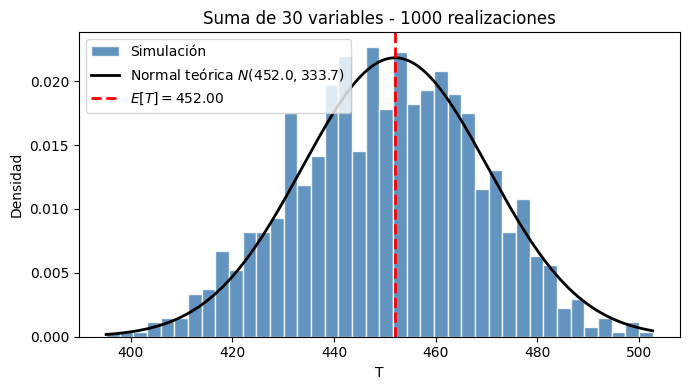

E[T] estimada:    450.4952 | Teórica: 452.0000
Var(T) estimada: 332.3116 | Teórica: 333.7333


In [12]:
import numpy as np
import matplotlib.pyplot as plt

N, n = 1000, 30

# 10 variables Uniformes U(10,20)
a = 10
b = 20

muestras_uniformes = np.random.uniform( a, b, size=(N, 10))

# 10 variables Exponenciales con lambda = 5
lam = 5

muestras_exp = np.random.exponential(scale=1/lam, size=(N, 10))

# 10 variables Gaussianas N(30, 5^2)
mu = 30
sigma = 5

muestras_gaussianas = np.random.normal(mu, sigma, size=(N, 10))

# Juntar las 30 variables
muestras = np.hstack((
    muestras_uniformes,
    muestras_exp,
    muestras_gaussianas
))

# Suma total de las 30 variables
T = muestras.sum(axis=1)

# Media teórica de la suma
# Uniforme: (a+b)/2
# Exponencial: 1/lambda
# Gaussiana: mu

mu_total = (
    10 * (a + b) / 2
    + 10 * (1 / lam)
    + 10 * mu
)

# Varianza teórica de la suma
# Uniforme: (b-a)^2/12
# Exponencial: 1/lambda^2
# Gaussiana: sigma^2

sigma2_total = (
    10 * ((b - a)**2 / 12)
    + 10 * (1 / lam**2)
    + 10 * sigma**2
)

# Desviación estándar
sigma_total = np.sqrt(sigma2_total)

# Histograma de las 1000 realizaciones
plt.figure(figsize=(7, 4))

plt.hist(T,bins=40,density=True,color='steelblue',edgecolor='white',alpha=0.85,label='Simulación')

# Normal teórica
x = np.linspace(T.min(), T.max(), 500)

normal = ( 1 / (sigma_total * np.sqrt(2*np.pi))* np.exp(-0.5 * ((x - mu_total) / sigma_total)**2))

plt.plot(x,normal,color='black',linewidth=2,label=rf'Normal teórica $N({mu_total:.1f},{sigma2_total:.1f})$')

# Media teórica
plt.axvline( mu_total,color='red',linestyle='--',lw=2,label=f'$E[T] = {mu_total:.2f}$')

plt.title('Suma de 30 variables - 1000 realizaciones')
plt.xlabel('T')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"E[T] estimada:    {T.mean():.4f} | Teórica: {mu_total:.4f}")
print(f"Var(T) estimada: {T.var():.4f} | Teórica: {sigma2_total:.4f}")


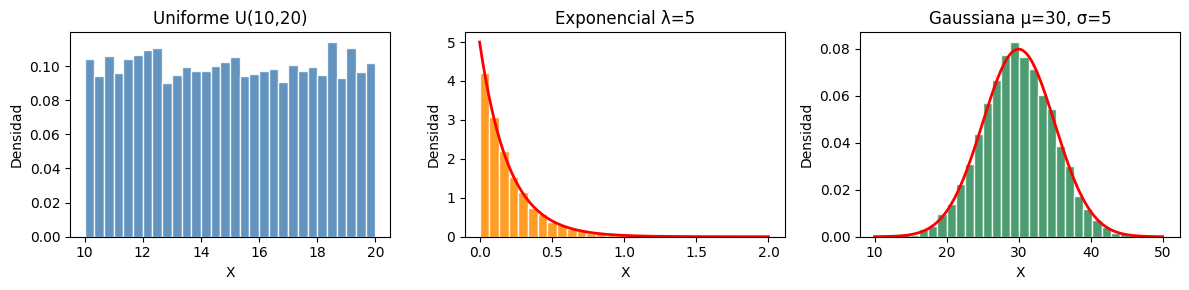

In [13]:
# Gráficos de las 3 distribuciones originales
plt.figure(figsize=(12, 3))

# Uniforme
plt.subplot(1, 3, 1)
plt.hist(muestras[:, 0:10].flatten(), bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Uniforme U(10,20)')
plt.xlabel('X')
plt.ylabel('Densidad')

# Exponencial
plt.subplot(1, 3, 2)
plt.hist(muestras[:, 10:20].flatten(), bins=30, density=True, color='darkorange', edgecolor='white', alpha=0.85)

x_exp = np.linspace(0, 2, 300)
plt.plot(x_exp, lam * np.exp(-lam * x_exp), 'r-', lw=2)

plt.title('Exponencial λ=5')
plt.xlabel('X')
plt.ylabel('Densidad')

# Gaussiana
plt.subplot(1, 3, 3)
plt.hist(muestras[:, 20:30].flatten(), bins=30, density=True, color='seagreen', edgecolor='white', alpha=0.85)

x_gauss = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)

normal_gauss = (1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x_gauss-mu)/sigma)**2))

plt.plot(x_gauss, normal_gauss, 'r-', lw=2)

plt.title('Gaussiana μ=30, σ=5')
plt.xlabel('X')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


### **Suma de VAs correlacionadas**

2.3.  Suma de VAs correlacionadas:

*   Genere un conjunto de 20 VAs **correlacionadas** con 1000 realizaciones. Use dos variables exponenciales base para construir dos grupos de 10 VAs cada uno mediante transformaciones lineales.

In [28]:
N = 1000
n = 20

muestras = np.zeros((N, n))
for i in range(N):

    X = np.random.exponential(scale=1/5)
    Y = np.random.exponential(scale=1/5)

    for j in range(10):
        muestras[i, j] = 2 * X + j

    for j in range(10):
        muestras[i, j + 10] = 3 * Y + j


0.015265338156528644


* Encuentre el ensamble (suma o promedio de las 20 VAs), grafique y compare. ¿Qué puede concluir con la información que ha encontrado hasta ahora?

Media del ensamble: 99.75
Desviación estándar: 6.74


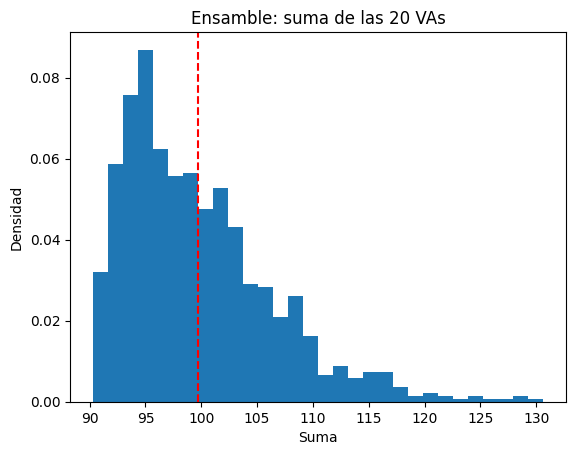

In [32]:
ensamble = np.sum(muestras, axis=1)
media = np.mean(ensamble)
std = np.std(ensamble)

print(f"Media del ensamble: {media:.2f}")
print(f"Desviación estándar: {std:.2f}")

plt.hist(ensamble, bins=30, density=True)
plt.axvline(media, color='red', linestyle='--',label=f"Media = {media:.2f}")
plt.title('Ensamble: suma de las 20 VAs')
plt.xlabel('Suma')
plt.ylabel('Densidad')
plt.show()


* Calcule ahora, la matriz de correlación de Pearson $\mathcal{P}$ (usando la función `pearsonr`) para las 20 distribuciones. Deberá encontrar una matriz de $[20 \times 20]$. ¿Qué estructura espera observar? ¿Qué puede concluir ahora?


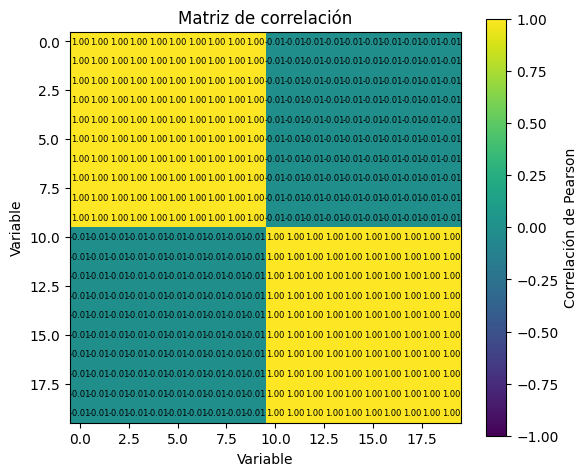

In [22]:
R = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        r, _ = pearsonr(muestras[:, i], muestras[:, j])
        R[i, j] = r

plt.figure(figsize=(6, 5))
plt.imshow(R, vmin=-1, vmax=1)
plt.colorbar(label='Correlación de Pearson')

for i in range(n):
    for j in range(n):
        plt.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=6)

plt.title('Matriz de correlación')
plt.xlabel('Variable')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


# Punto 3: Procesos aleatorios



## 3.1. Señal cosenoidal con fase aleatoria

3.1.1 Genere N arreglos del proceso aleatorio $cos(2 \pi f_c t + Φ) + 1$ donde $Φ \thicksim U [0,2\pi]$ y grafique al menos 5 de ellos en una figura.

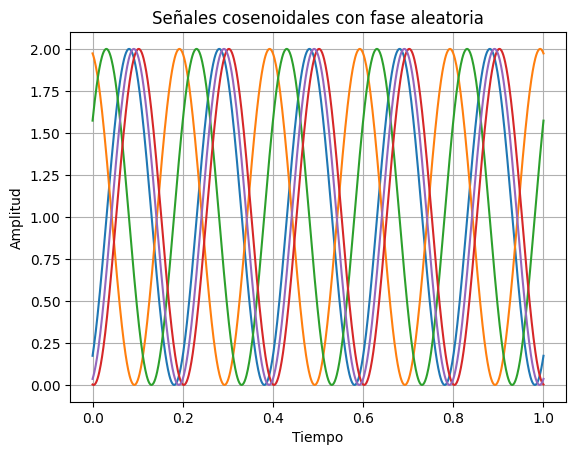

[[0.17345158 0.19155798 0.21046381 ... 0.1397079  0.15616252 0.17345158]
 [1.97323325 1.96552603 1.95686404 ... 1.98575387 1.97997809 1.97323325]
 [1.57318303 1.59866423 1.62355343 ... 1.52054602 1.54713504 1.57318303]
 ...
 [0.56617332 0.53805852 0.51040051 ... 0.62366167 0.59471711 0.56617332]
 [1.14960402 1.11844171 1.08716228 ... 1.21145416 1.18061839 1.14960402]
 [1.8987703  1.91211081 1.92454936 ... 1.86943711 1.88454105 1.8987703 ]]


In [35]:
N = 100
fc = 5
t = np.linspace(0, 1, 1000)

señales = np.zeros((N, len(t)))

for i in range(N):
    phi = np.random.uniform(0, 2*np.pi)
    señales[i, :] = np.cos(2*np.pi*fc*t + phi) + 1

for i in range(5):
    plt.plot(t, señales[i, :])

plt.title('Señales cosenoidales con fase aleatoria')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.grid()
plt.show()


3.1.2 Varíe el número de arreglos entre [10, 100, 1000], calcule la media a travez del ensamble para cada tiempo y grafique el resultado. Qué puede concluir del comportamiento de la media del ensamble al variar la cantidad de arreglos generados del proceso aleatorio?

para N = 10, media temporal = 0.9999
para N = 100, media temporal = 1.0000
para N = 1000, media temporal = 1.0000


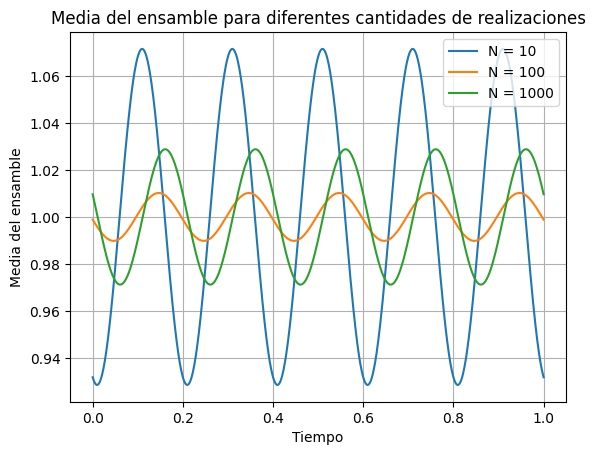

In [56]:
fc = 5
t = np.linspace(0, 1, 1000)

Ns = [10, 100, 1000]

for N in Ns:

    señales = np.zeros((N, len(t)))

    for i in range(N):
        phi = np.random.uniform(0, 2*np.pi)
        señales[i, :] = np.cos(2*np.pi*fc*t + phi) + 1

    # Media del ensamble para cada instante t
    media = np.mean(señales, axis=0)

    # Offset promedio de todo el ensamble
    offset = np.mean(señales)

    print(f'para N = {N}, media temporal = {offset:.4f}')
    plt.plot(t, media, label=f'N = {N}')

plt.title('Media del ensamble para diferentes cantidades de realizaciones')
plt.xlabel('Tiempo')
plt.ylabel('Media del ensamble')
plt.legend()
plt.grid()
plt.show()


3.1.3 Calcule la media temporal para cada arreglo y grafique el resultado. Qué puede inferir del proceso aleatorio?

converge :

Al calcular la media temporal de cada realización, se observa que esta se aproxima al valor de 1, que corresponde a la media del ensamble o media estadística del proceso. Por lo tanto, podemos concluir que la media temporal converge hacia la media estadística del proceso, lo que es una característica de un proceso ergódico respecto a la media.



# Punto 4: Procesos aleatorios y ergodicidad, caso del movimiento browniano.

4.1. Considere la función "brownian motion(M,T)" donde M=1000 y T=10. Genere el ensamble del proceso aleatorio, dibújelo y calcule la media del ensamble (para todas las filas del ensamble) y la media temporal (para todas las columnas). Qué puede concluir?




In [16]:
def brownian_motion(M,T):
  # M: Numero de puntos en el eje temporal

  dt = T / M  # Time step

  # Simulate multiple realizations of Brownian motion

  # Generate the increments for Brownian motion
  dW = np.random.normal(0, np.sqrt(dt), M-1)
  W_t = np.concatenate(([0], np.cumsum(dW)))  # Inicia en W(0) = 0 y accumacumula los incrementos
  return W_t


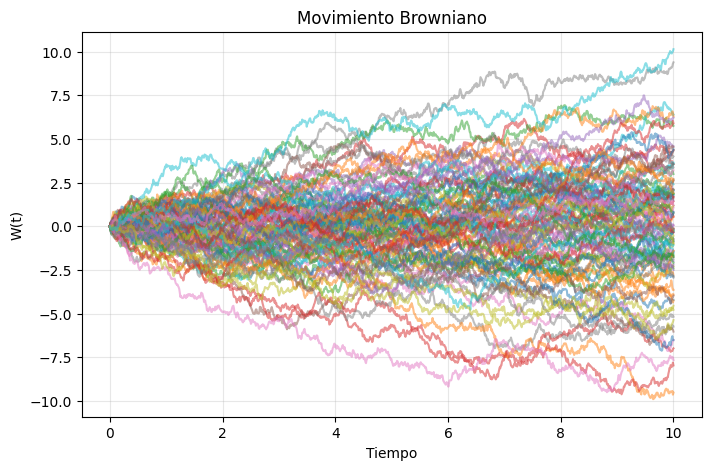

Media del ensamble: 0.0019332852181615898
Media temporal: 0.0019332852181615935


In [58]:
M = 1000
T = 10
N = 1000

t = np.linspace(0, T, M)

ensamble = np.zeros((N, M))

for i in range(N):
    ensamble[i, :] = brownian_motion(M, T)

# Gráfica del ensamble
plt.figure(figsize=(8,5))

for i in range(100):
    plt.plot(t, ensamble[i, :], alpha=0.5)

plt.title("Movimiento Browniano")
plt.xlabel("Tiempo")
plt.ylabel("W(t)")
plt.grid(alpha=0.3)
plt.show()

# Media del ensamble
media_ensamble = np.mean(ensamble, axis=0)

# Media temporal de cada realización
media_temporal = np.mean(ensamble, axis=1)

print("Media del ensamble:", np.mean(media_ensamble))
print("Media temporal:", np.mean(media_temporal))


Los resultados están relacionados con la Ley de los Grandes Números, ya que al utilizar un gran número de realizaciones, la media del ensamble se aproxima al valor esperado del proceso, que para el movimiento Browniano es cero. En este caso se obtuvo una media de aproximadamente 0.00193, cercana a cero.

Solo una aclaración: la Ley de los Grandes Números explica la convergencia del promedio al valor esperado, pero no es exactamente lo mismo que decir que el proceso es ergódico. Son conceptos relacionados, pero diferentes


# Punto 5: Calidad de Señal en una Red Inalámbrica WiFi

---

### Contexto general

Una empresa de telecomunicaciones está evaluando la migración de su infraestructura interna de **WiFi 5** a **WiFi 6**. Para apoyar esta decisión con evidencia estadística, se realizaron mediciones en **90 puntos fijos** distribuidos en tres pisos de un edificio de oficinas. En cada punto se registraron las mismas variables con ambas tecnologías.

Los datos se encuentran en dos archivos CSV: `wifi5_datos.csv` y `wifi6_datos.csv`

Ambos archivos contienen **exactamente los mismos 90 puntos de medición** (`punto_id` del 1 al 90) con las siguientes columnas:


* `punto_id`: Identificador único del punto de medición
* `piso`: Piso del edificio: `Piso1`, `Piso2` o `Piso3`
* `rssi_dbm`:  Potencia de señal recibida en dBm
* `intermitencia`: Intermitencia de servicio registrada: `Si` o `No`

**Nota:** El RSSI (*Received Signal Strength Indicator*) mide la potencia de la señal en dBm. Valores más cercanos a 0 son mejores.

Referencia orientativa:

* 0 dbm: señal ideal, difícil de lograr en la práctica.
* -40 a -60 dBm: señal idónea con tasas de transferencia estables.
* -60 dBm: enlace bueno.
* -70 dBm: enlace medio-bajo.
* 80 dBm: es la señal mínima aceptable para establecer la conexión.

---


## 5.1 — Comparación Global del RSSI: WiFi 5 vs. WiFi 6

El equipo de ingeniería quiere saber si, **considerando todo el edificio en conjunto**, existe alguna diferencia en la calidad de señal entre ambas tecnologías.

Los 90 puntos físicos son los mismos para ambas tecnologías. En este punto se tratarán las muestras como **independientes** para el análisis comparativo entre grupos.



### 5.1.1 — Análisis exploratorio: histogramas y estadísticos descriptivos

Antes de aplicar cualquier prueba estadística, es fundamental entender visualmente cómo se distribuyen los datos.

**Procedimiento:**
- Construya y presente una tabla que incluya las siguientes columnas: media, mediana, desviación estándar, varianza, mínimo y máximo del RSSI para cada tecnología.

In [59]:
import pandas as pd
import seaborn as sns
import scipy as sc


In [60]:

# lectura de los datos desde el .CSV
wifi5 = pd.read_csv('wifi5_datos.csv')
wifi6 = pd.read_csv('wifi6_datos.csv')

# Calculo de los momentos estadísticos para wifi5
wifi5_mean = wifi5['rssi_dbm'].mean()
wifi5_median = wifi5['rssi_dbm'].median()
wifi5_std = wifi5['rssi_dbm'].std()
wifi5_var = wifi5['rssi_dbm'].var()
wifi5_min = wifi5['rssi_dbm'].min()
wifi5_max = wifi5['rssi_dbm'].max()

# Calculo de los momentos estadísticos para wifi6
wifi6_mean = wifi6['rssi_dbm'].mean()
wifi6_median = wifi6['rssi_dbm'].median()
wifi6_std = wifi6['rssi_dbm'].std()
wifi6_var = wifi6['rssi_dbm'].var()
wifi6_min = wifi6['rssi_dbm'].min()
wifi6_max = wifi6['rssi_dbm'].max()

# Tabala comparativa
tabla1 = pd.DataFrame({
    'Tegnología': ['WiFi 5', 'WiFi 6'],
    'Media': [wifi5_mean, wifi6_mean],
    'Mediana': [wifi5_median, wifi6_median],
    'Desviación estándar': [wifi5_std, wifi6_std],
    'Varianza': [wifi5_var, wifi6_var],
    'Mínimo': [wifi5_min, wifi6_min],
    'Máximo': [wifi5_max, wifi6_max]
})

tabla1.to_csv('tabla1.csv', index=False)
tabla511 = pd.read_csv('tabla1.csv')
tabla511


,Tegnología,Media,Mediana,Desviación estándar,Varianza,Mínimo,Máximo
0,WiFi 5,-67.662222,-67.05,8.907409,79.341928,-94.2,-50.4
1,WiFi 6,-67.051111,-66.95,7.902897,62.455785,-86.4,-44.5


- Grafique en una sola figura el histograma de `rssi_dbm` para WiFi5 y WiFi6 (un color diferente por tecnología). Agregue líneas verticales indicando la media de cada grupo.

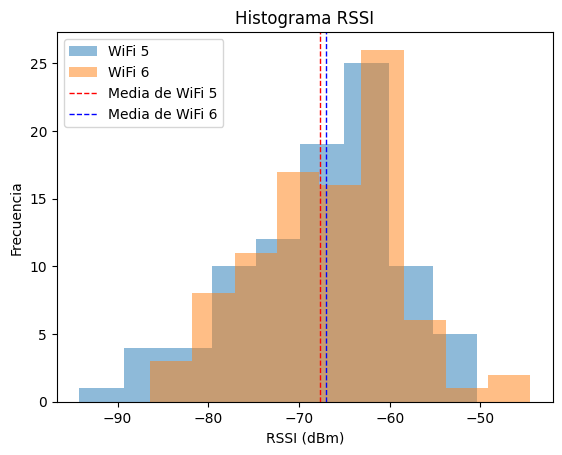

In [66]:
# Histograma

# Definición de bins comunes
all_data = np.concatenate([wifi5['rssi_dbm'], wifi6['rssi_dbm']])

bins = np.linspace(all_data.min(), all_data.max(), 30)  # mismo rango para ambas gráficas

plt.hist(wifi5['rssi_dbm'],  bins='fd', alpha=0.5, label='WiFi 5')
plt.hist(wifi6['rssi_dbm'],  bins='fd', alpha=0.5, label='WiFi 6')

plt.title('Histograma RSSI')
plt.xlabel('RSSI (dBm)')
plt.ylabel('Frecuencia')

plt.axvline(wifi5_mean, color='r', linestyle = '--', linewidth = 1, label = 'Media de WiFi 5')
plt.axvline(wifi6_mean, color='b', linestyle = '--', linewidth = 1, label = 'Media de WiFi 6')
plt.legend()
plt.show()

- Grafique el diagrama de cajas y bigotes (boxplot) en una sola figura para la variable `rssi_dbm` usando los datos de las tecnologías WiFi5 y WiFi6 (un color diferente por tecnología)


**Preguntas:**
- ¿Con base únicamente en los estadísticos y las distribuciones se puede concluir si las tecnologías son similares o distintas?

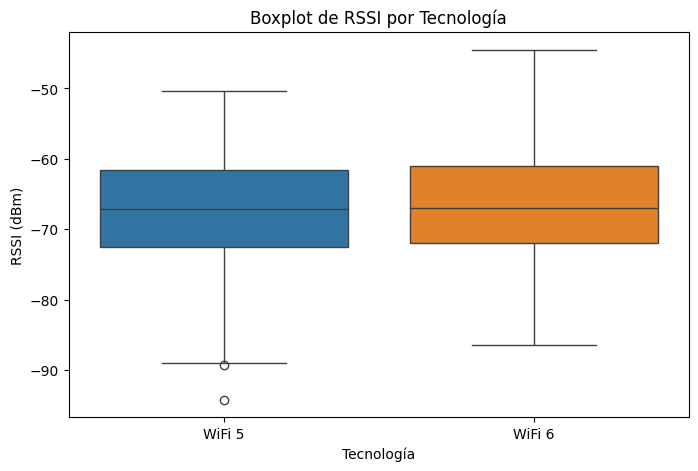

In [63]:
# Boxplot

wifi5['Tecnologia'] = 'WiFi 5'
wifi6['Tecnologia'] = 'WiFi 6'

df = pd.concat([wifi5, wifi6])

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Tecnologia', y='rssi_dbm', hue='Tecnologia')

plt.title('Boxplot de RSSI por Tecnología')
plt.xlabel('Tecnología')
plt.ylabel('RSSI (dBm)')

plt.show()

Analizando los gráficos y los diferentes momentos estadísticos se puede evidenciar cierta similitud entre ambas distribuciones, sin embargo, aunque presenta diferencias significativas en la desviación estadar, el análisis visual no es suficiente para determinar si las diferencias son estadísticamente significativas, por lo que se requieren pruebas de hipótesis.


### 5.1.2 Pruebas estadísticas:

**NOTA:** Lea la documentación de cada prueba, identificando la hipótesis nula en cada caso, y el criterio para aceparla o rechazarla. Adicionalmente, para las pruebas `scipy.stats.ttest_ind` y `scipy.stats.mannwhitneyu` busque el significado del parámetro `alternative` asociado a los tipos de "colas".

# Hipostesis nulas y criterios de aceptación:
**Levene:** la hipótesis nula (**H0**) de la prueba indica si las muestras provienen de poblaciones con varianzas iguales, con un $α$=0.05 como criterio de aceptación por defecto; retorna el valor del p-value que de ser menor al $\alpha$ indica que las varianzas no son iguales.

**Shapiro:** la hipóstesis nula de la prueba indica si los datos se extrajeron de una distribución normal, su criterio de aceptación es $\alpha$=0.05 de no cumplirse indica que los datos no probienen de una distribución normal.

**Ttest_ind:** se usa cuando los datos siguen una distribución normal, su hipótesis nula dice si dos muestras independientes tienen promedios identicos, su umbral de aceptación varía entre: 0.01 < $\alpha$ < 0.05; el parámetro 'alternative' define la hipótesis alternativa, por defecto bilateral (two-sided) señala que los promedios de las muestras son diferenetes, menor (less) señala que el promedio de la segunda muestra es menos, y mayor (greater) señala que que el promedio de la segunda muestra es mayor.

**Mannwhitneyu:** se usa cuando los datos no siguen una distribución normal, su hipótesis nula dice si las distribuciones de las dos muestras son igules, el criterio de aceptación se establece en $\alpha$=0.05, si el p-value de la prueba es munor a este se rechaza la hipótesis nula; el parámetro 'alternative' indica la hipótesis alternativa: bilateral (two-sided) señala que las distribuciones son diferentes, menor (less) señala que la distribución de la primera muestra es menor que la segunda distribución, mayor (greater) señala que la primer distribución es mayor que la segunda distribucíon.

Tomado de: https://docs.scipy.org/doc/scipy/reference/stats.html

*   Determine si las varianzas de ambos grupos son iguales (cumplen el criterio de homocedasticidad). Para ello utilice la prueba Levene usando la libreria `scipy.stats.levene`.

In [67]:
# Prueba de homocedasticidad

# Conversión a arreglos
arr_wifi5 = wifi5['rssi_dbm'].to_numpy()
arr_wifi6 = wifi6['rssi_dbm'].to_numpy()

# Prueba
stat, p = sc.stats.levene(arr_wifi5, arr_wifi6, center = 'median')

if p > 0.05:
  print('P- value obtenido: ', p)
  print('Se acoje la hipótesis nula, las varianzas son iguales')
else:
  print('P-value obtenirdo: ', p)
  print('Se acoje a hpótesis alternativa, las varianzas son distintas')

P- value obtenido:  0.4749428373013662
Se acoje la hipótesis nula, las varianzas son iguales


*   Determine si las medias de ambos grupos son iguales. Para esto, primero determine si los dos grupos siguen una distribución normal mediante la prueba `scipy.stats.shapiro`, luego aplique `scipy.stats.ttest_ind` o `scipy.stats.mannwhitneyu` de acuerto con el resultado de la prueba de normalidad.

In [68]:
# Prueba de normalidad y promedio
# Usando los intervalos de la anterior prueba
shapiro5 = sc.stats.shapiro(arr_wifi5)
shapiro6 = sc.stats.shapiro(arr_wifi6)

if shapiro5[1] > 0.05 and shapiro6[1] > 0.05:
  print('P-value obtenido para WiFi 5: ', shapiro5[1])
  print('P-value obtenido para WiFi 6: ', shapiro6[1])
  print('Se acoje la hipótesis nula, los datos provienen de una distribución normal')
else:
  print('P-value obtenido para WiFi 5: ', shapiro5[1])
  print('P-value obtenido para WiFi 6: ', shapiro6[1])
  print('Se acoje la hipótesis alternativa, los datos no provienen de una distribución normal')

P-value obtenido para WiFi 5:  0.029833734849055795
P-value obtenido para WiFi 6:  0.13124030041766044
Se acoje la hipótesis alternativa, los datos no provienen de una distribución normal


In [69]:
# Prueba de MannWhitney
MannWhitney = sc.stats.mannwhitneyu(arr_wifi5, arr_wifi6, alternative = 'two-sided')

if MannWhitney[0] > 0.05:
  print('P-value obtenido: ', MannWhitney[1])
  print('Se acoje la hipótesis nula, las distribuciones son iguales')
else:
  print('P-value obtenido: ', MannWhitney[1])
  print('Se acoje la hipótesis alternativa, las distribuciones son distintas')

P-value obtenido:  0.8034294938585077
Se acoje la hipótesis nula, las distribuciones son iguales


**Preguntas:**
- ¿Existe diferencia estadísticamente significativa entre el RSSI de WiFi5 y WiFi6 a nivel global?
- ¿Este resultado global es suficiente para tomar la decisión de migración? ¿O podría haber información importante que se esté perdiendo al visualizar las pruebas de manera global?

**Respuestas:**
1. De acuerdo a las pruebas realizadas no hay diferencias significativa entre la distribución de los datos RSSI para ambas tecnologías, esto indica que no existe diferencia estadísticamente significativa entre las distribuciones de RSSI de WiFi 5 y WiFi 6 a nivel global, ambas tecnologías ofrecen niveles de señal similares en promedio en el edificio completo.

2. Aunque a nivel global no se encontraron diferencias significativas, este resultado no es suficiente para tomar una decisión de migración, ya que el análisis agregado puede ocultar comportamientos locales.

---
## 5.2 — Análisis por Piso: Comparación de RSSI entre Tecnologías

El punto 5.1 ofreció una visión global del edificio. Sin embargo, un ingeniero de redes sabe que la cobertura puede variar significativamente según la zona.

Repita **exactamente el mismo análisis** para las tecnologías WiFI5 y WiFi6 (dssi_dbm) pero aplicado de forma **independiente para cada piso**.



### 5.2.1 — Análisis exploratorio por piso

**procedimiento:**
- Grafique un **boxplot y distribuciones** del `rssi_dbm` para cada piso, mostrando WiFi5 y WiFi6 lado a lado.


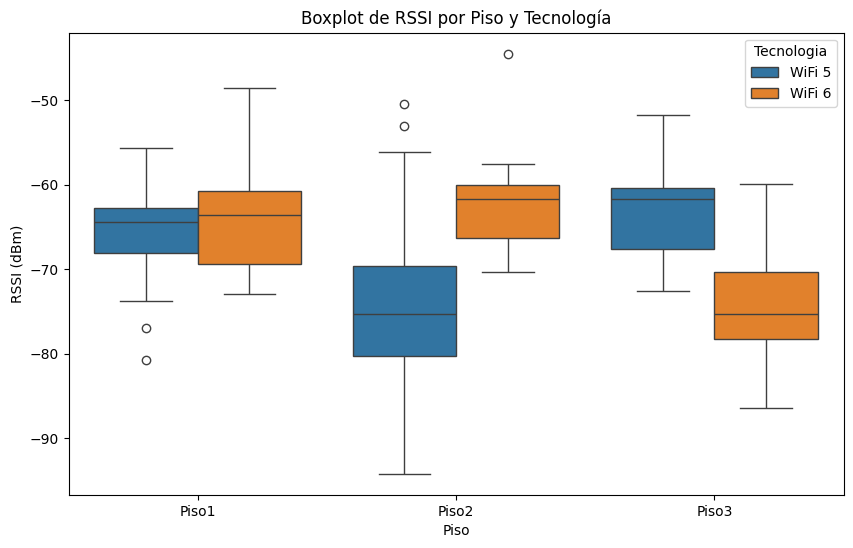

In [72]:
# Agregamos la etiqueta de tecnología para que Seaborn pueda diferenciarlas por color
wifi5['Tecnologia'] = 'WiFi 5'
wifi6['Tecnologia'] = 'WiFi 6'

# Unimos ambos DataFrames
df_total = pd.concat([wifi5, wifi6])

# 2. VISUALIZACIÓN CON SEABORN (Fuera del bucle)
plt.figure(figsize=(10, 6))

# x='piso' separa los bloques en el eje X. hue='Tecnologia' los pone lado a lado.
sns.boxplot(data=df_total, x='piso', y='rssi_dbm', hue='Tecnologia')

plt.title('Boxplot de RSSI por Piso y Tecnología')
plt.xlabel('Piso')
plt.ylabel('RSSI (dBm)')
plt.show()

- Calcule media, desviación estándar y varianza del RSSI para cada combinación piso-tecnología.

In [77]:
# 3. ANÁLISIS ESTADÍSTICO
pisos = ["Piso1", "Piso2", "Piso3"]

for piso in pisos:
    print(f"\n{piso} ")

    # Filtramos los datos por piso
    data5 = wifi5[wifi5["piso"] == piso]["rssi_dbm"]
    data6 = wifi6[wifi6["piso"] == piso]["rssi_dbm"]

    print(f"Desviación estándar WiFi5:: {np.std(data5):.4f}  | Desviación estándar WiFi6: {np.std(data6):.4f}")
    print(f"Varianza WiFi5:: {np.var(data5):.4f}  | Varianza WiFi6: {np.var(data6):.4f}")
    print(f"Media WiFi5:: {np.mean(data5):.4f}  | Media WiFi6: {np.mean(data6):.4f}")

    # Test de Levene (Homogeneidad de varianzas)
    _, p_levene = sc.stats.levene(data5, data6)

    # Test de Shapiro
    _, p5 = sc.stats.shapiro(data5)
    print("shapiro p5:", p5)
    _, p6 = sc.stats.shapiro(data6)
    print("shapiro p6:", p6)

    # Decisión sobre qué test aplicar
    if p5 > 0.05 and p6 > 0.05:
        # Ambos son normales -> t-test
        _, p_val = sc.stats.ttest_ind(data5, data6, equal_var=(p_levene > 0.05))
        print("t-test p:", p_val)
    else:
        # Al menos uno no es normal -> Mann-Whitney
        _, p_val = sc.stats.mannwhitneyu(data5, data6)
        print("Mann-Whitney p:", p_val)


Piso1 
Desviación estándar WiFi5:: 5.5957  | Desviación estándar WiFi6: 5.6990
Varianza WiFi5:: 31.3120  | Varianza WiFi6: 32.4783
Media WiFi5:: -65.2000  | Media WiFi6: -64.1800
shapiro p5: 0.1998996539413062
shapiro p6: 0.20289636565512226
t-test p: 0.49436009311090434

Piso2 
Desviación estándar WiFi5:: 10.2760  | Desviación estándar WiFi6: 5.0018
Varianza WiFi5:: 105.5972  | Varianza WiFi6: 25.0185
Media WiFi5:: -74.4133  | Media WiFi6: -62.2567
shapiro p5: 0.5138553378217914
shapiro p6: 0.00470114043122038
Mann-Whitney p: 1.997064436626771e-06

Piso3 
Desviación estándar WiFi5:: 5.3327  | Desviación estándar WiFi6: 6.1480
Varianza WiFi5:: 28.4373  | Varianza WiFi6: 37.7981
Media WiFi5:: -63.3733  | Media WiFi6: -74.7167
shapiro p5: 0.25870637637366994
shapiro p6: 0.5179979033881605
t-test p: 4.1394159383657646e-10


**Preguntas:**
- ¿Visualmente, en qué pisos parece haber diferencia entre las medias de WiFi5 y WiFi6? ¿En cuáles parecen similares?

Visualmente y estadísticamente:



1.   En Piso 1 las tecnologías presentan comportamientos similares (no hay diferencia significativa).
2.   En Piso 2 WiFi 6 presenta una señal considerablemente mejor (menos negativa).
3.   En Piso 3 ocurre lo contrario: WiFi 5 presenta mejor desempeño.


Esto evidencia que el comportamiento depende fuertemente del piso y que el análisis global oculta estas diferencias.

### 5.2.2 — test comparativo por cada piso

* Para cada piso (**Piso1, Piso2, Piso3**) de forma independiente, realice las pruebas estadisticas para determinar si las varianzas y las medias son similares:





In [78]:
import scipy.stats as stats

pisos = ["Piso1", "Piso2", "Piso3"]

for piso in pisos:

    data5 = wifi5[wifi5["piso"] == piso]["rssi_dbm"]
    data6 = wifi6[wifi6["piso"] == piso]["rssi_dbm"]

    print(f"\n--- {piso} ---")

    # 1. Prueba de igualdad de varianzas
    _, p_levene = stats.levene(data5, data6)
    print("Levene p =", p_levene)

    if p_levene > 0.05:
        print("Varianzas similares")
    else:
        print("Varianzas diferentes")

    # 2. Prueba de normalidad
    _, p5 = stats.shapiro(data5)
    _, p6 = stats.shapiro(data6)

    # 3. Prueba de igualdad de medias
    if p5 > 0.05 and p6 > 0.05:

        # Si son normales → t-test
        _, p_media = stats.ttest_ind(
            data5,
            data6,
            equal_var=(p_levene > 0.05)
        )

        print("Prueba de medias: t-test")

    else:

        # Si no son normales → Mann-Whitney
        _, p_media = stats.mannwhitneyu(
            data5,
            data6,
            alternative="two-sided"
        )

        print("Prueba de medias: Mann-Whitney")

    print("p =", p_media)

    if p_media > 0.05:
        print("Medias similares")
    else:
        print("Medias diferentes")



--- Piso1 ---
Levene p = 0.657909112885847
Varianzas similares
Prueba de medias: t-test
p = 0.49436009311090434
Medias similares

--- Piso2 ---
Levene p = 0.007059592147833247
Varianzas diferentes
Prueba de medias: Mann-Whitney
p = 1.997064436626771e-06
Medias diferentes

--- Piso3 ---
Levene p = 0.5189535685341322
Varianzas similares
Prueba de medias: t-test
p = 4.1394159383657646e-10
Medias diferentes



## 5.3 — Asociación entre Tecnología e Intermitencias de Servicio

El departamento de TI registró si cada punto de medición presentó **intermitencias de servicio** (caídas de conexión, latencia elevada, etc.) durante la semana de mediciones. La columna `intermitencia` toma los valores `Si` o `No`.

Se quiere determinar si existe asociación estadística entre la tecnología utilizada y la ocurrencia de intermitencias. El análisis se realizará en **dos niveles**: primero globalmente y luego por piso.

Tanto `tecnologia` como `intermitencia` son **variables categóricas**.


### 5.3.1 — Análisis global: tabla de contingencia y exploración

Considere todos los 180 registros (90 de WiFi5 + 90 de WiFi6) en conjunto, sin distinguir por piso.

**Instrucciones:**
- Construya una **tabla de contingencia 2×2** cruzando `tecnologia` (WiFi5 / WiFi6) vs. `intermitencia` (Si / No). Reporte las frecuencias. Utlice la función `pd.crosstab`.

In [80]:
wifi5['tecnologia'] = 'WiFi5'
wifi6['tecnologia'] = 'WiFi6'

# Unir los 180 registros
df = pd.concat([wifi5, wifi6])

# Tabla de contingencia 2x2
tabla2 = pd.crosstab(
    df['tecnologia'],
    df['intermitencia']
)

print(tabla2)


intermitencia  No  Si
tecnologia           
WiFi5          44  46
WiFi6          45  45


- Grafique las frecuencias en dos gráficos de barras.

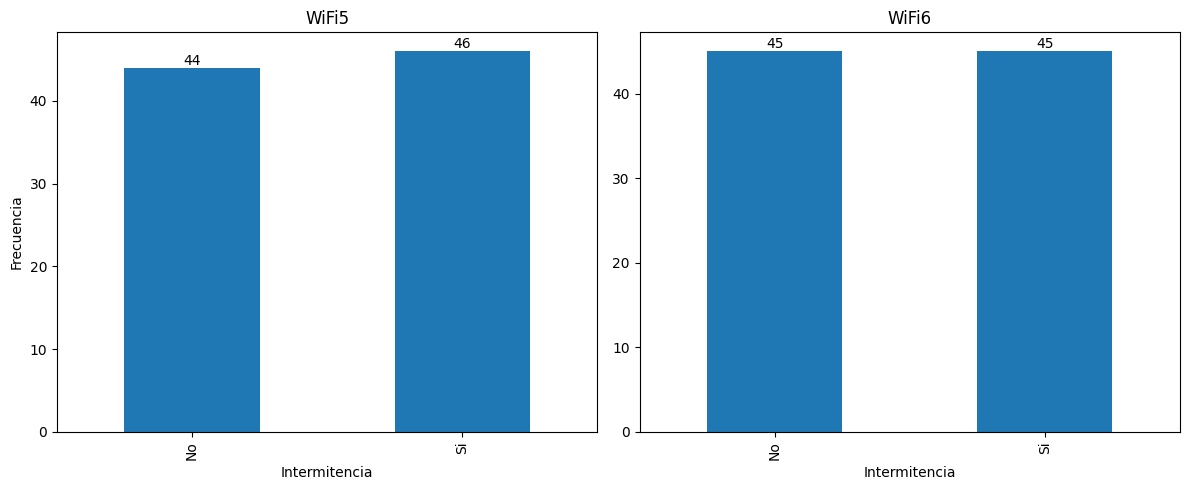

In [83]:
# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# WiFi5
tabla2.loc['WiFi5'].plot(
    kind='bar',
    ax=axes[0],
    title='WiFi5'
)
axes[0].bar_label(axes[0].containers[0])
axes[0].set_xlabel('Intermitencia')
axes[0].set_ylabel('Frecuencia')

# WiFi6
tabla2.loc['WiFi6'].plot(
    kind='bar',
    ax=axes[1],
    title='WiFi6'
)
axes[1].bar_label(axes[1].containers[0])
axes[1].set_xlabel('Intermitencia')

plt.tight_layout()
plt.show()


**Preguntas:**
- ¿A primera vista, las tasas de intermitencia de WiFi5 y WiFi6 parecen similares o muy diferentes a nivel global?

**Respuesta:** no se evidencian grandes diferencias en las tasas de intermitencia a nivel global, con base en la tabla de contingencia y los gráficos de barras se observa una pequeña diferencia para la tecnología WIFi 5, donde se presenta más intermitencia en las pruebas.

### 5.3.2 — Pruebas estadisticas

**Procedimineto:**
- Determine si existe una asociación estadísticamente significativa entre la tecnología y las intermitencias a nivel global. Para ello, utilice la prueba `stats.chi2_contingency` con base en la tabla de contingencia.


In [86]:
chi2, p, dof, expected = sc.stats.chi2_contingency(tabla2, correction=False)

alpha = 0.05

print(f"P-Value obtenido: {p:.4f}")

if p > alpha:
    print("Se acoje la hipótesis nula, Las variables son independientes")
else:
    print("Se rechaza la hipótesis nula: existe asociación entre las variables.")


P-Value obtenido: 0.8815
Se acoje la hipótesis nula, Las variables son independientes


Hipótesis :

H₀: la tecnología y la intermitencia son independientes.

H₁: existe asociación entre la tecnología y la intermitencia.

## 5.4 — Asociación entre Tecnología e Intermitencias de Servicio por piso

5.4.1: Realice un grafico de barras donde se evidencien la cantidad de intermitecias por tecnología en cada piso de manera independiente.

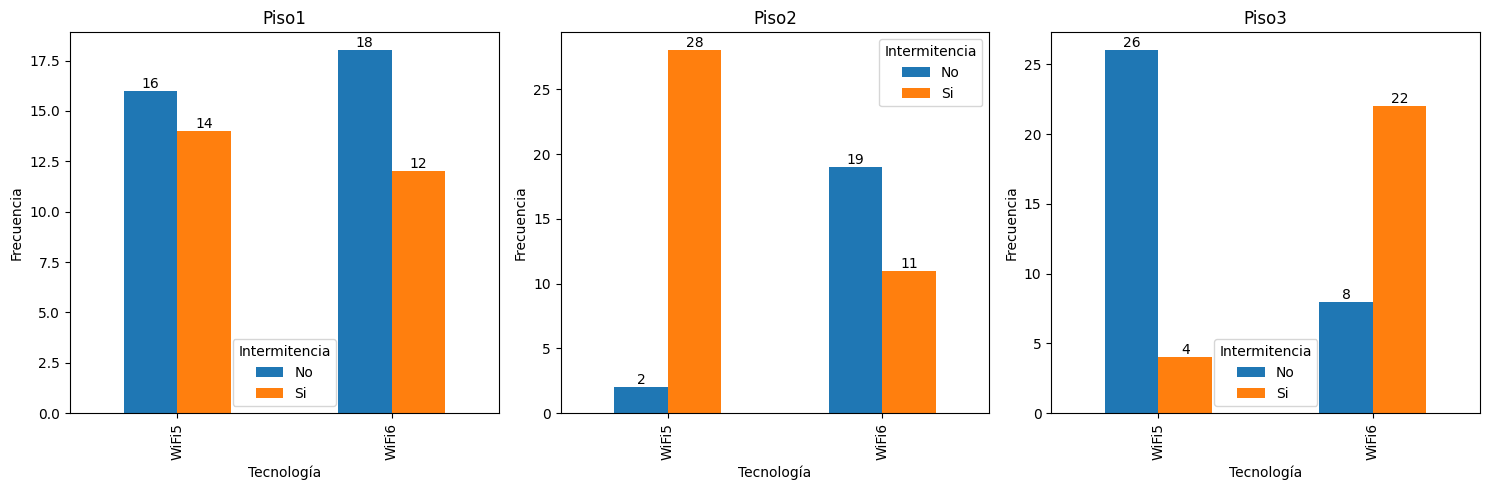

In [88]:
# Unir los datos
df = pd.concat([wifi5, wifi6])

# Crear un gráfico por cada piso
pisos = ["Piso1", "Piso2", "Piso3"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, piso in enumerate(pisos):

    datos_piso = df[df["piso"] == piso]

    tabla = pd.crosstab(
        datos_piso["tecnologia"],
        datos_piso["intermitencia"]
    )

    tabla.plot(
        kind="bar",
        ax=axes[i],
        title=piso
    )

    axes[i].set_xlabel("Tecnología")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(title="Intermitencia")

    axes[i].bar_label(axes[i].containers[0])
    axes[i].bar_label(axes[i].containers[1])

plt.tight_layout()
plt.show()


5.4.2: Aplique una prueba estadistica por piso para determinar si existe una asociación estadisticamente significativa entre tecnología e intermitencias en el servicio.

In [89]:
import scipy.stats as stats
import pandas as pd

df = pd.concat([wifi5, wifi6])

pisos = ["Piso1", "Piso2", "Piso3"]

for piso in pisos:

    # Filtrar los datos del piso
    datos_piso = df[df["piso"] == piso]

    # Tabla de contingencia
    tabla = pd.crosstab(
        datos_piso["tecnologia"],
        datos_piso["intermitencia"]
    )

    # Chi-cuadrado
    chi2, p, dof, expected = stats.chi2_contingency(
        tabla,
        correction=False
    )

    print(f"\n--- {piso} ---")
    print(tabla)
    print(f"Chi2 = {chi2:.4f}")
    print(f"p-value = {p:.4f}")

    if p < 0.05:
        print("Existe asociación estadísticamente significativa.")
    else:
        print("No existe asociación estadísticamente significativa.")



--- Piso1 ---
intermitencia  No  Si
tecnologia           
WiFi5          16  14
WiFi6          18  12
Chi2 = 0.2715
p-value = 0.6023
No existe asociación estadísticamente significativa.

--- Piso2 ---
intermitencia  No  Si
tecnologia           
WiFi5           2  28
WiFi6          19  11
Chi2 = 21.1722
p-value = 0.0000
Existe asociación estadísticamente significativa.

--- Piso3 ---
intermitencia  No  Si
tecnologia           
WiFi5          26   4
WiFi6           8  22
Chi2 = 21.9910
p-value = 0.0000
Existe asociación estadísticamente significativa.
